In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [61]:
df = sns.load_dataset("titanic")

print("Ukuran Dataset:", df.shape)
print("\nKolom Dataset:")
print(df.columns)

df.head()

Ukuran Dataset: (891, 15)

Kolom Dataset:
Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [62]:
print(df.isnull().sum())

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


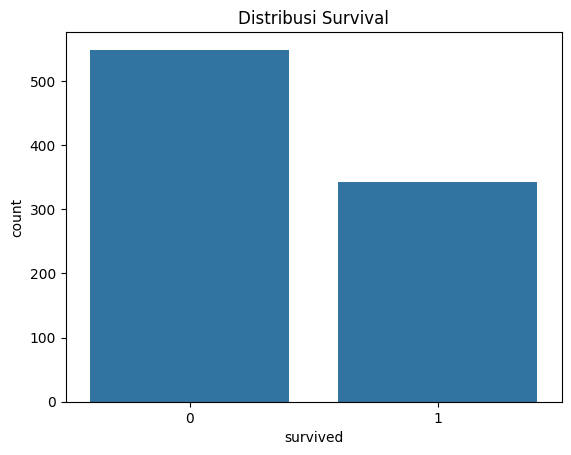

In [63]:
sns.countplot(x='survived', data=df)
plt.title("Distribusi Survival")
plt.show()

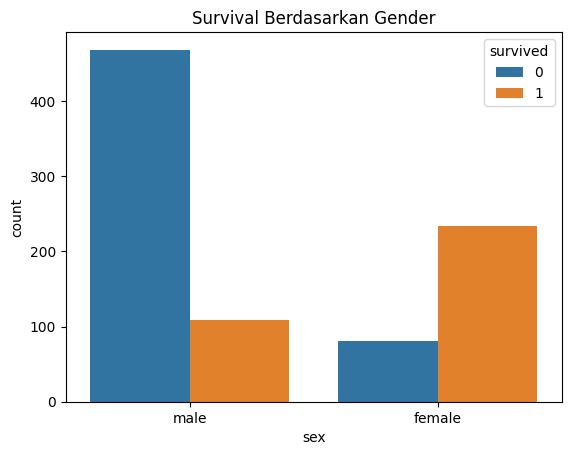

In [64]:
sns.countplot(x='sex', hue='survived', data=df)
plt.title("Survival Berdasarkan Gender")
plt.show()

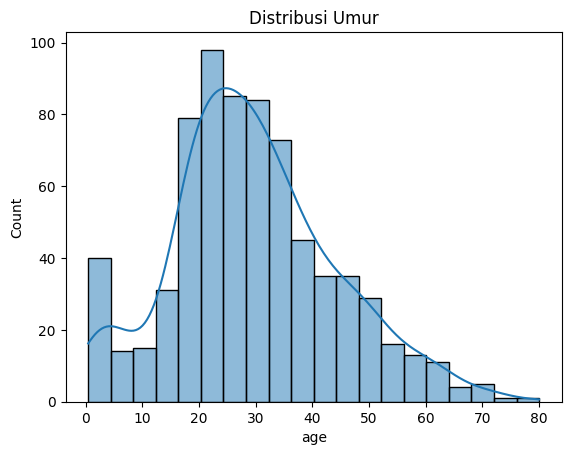

In [65]:
sns.histplot(df['age'], kde=True)
plt.title("Distribusi Umur")
plt.show()

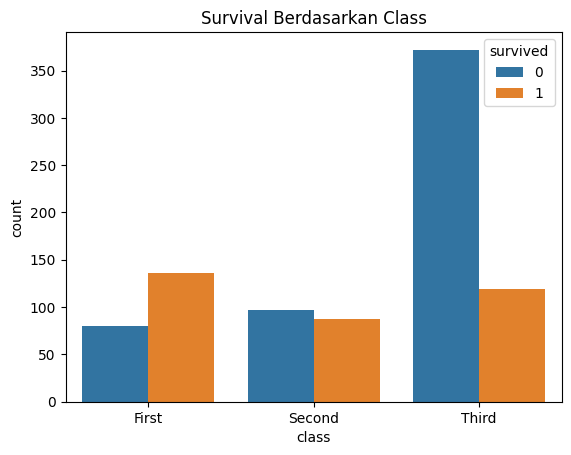

In [66]:
sns.countplot(x='class', hue='survived', data=df)
plt.title("Survival Berdasarkan Class")
plt.show()

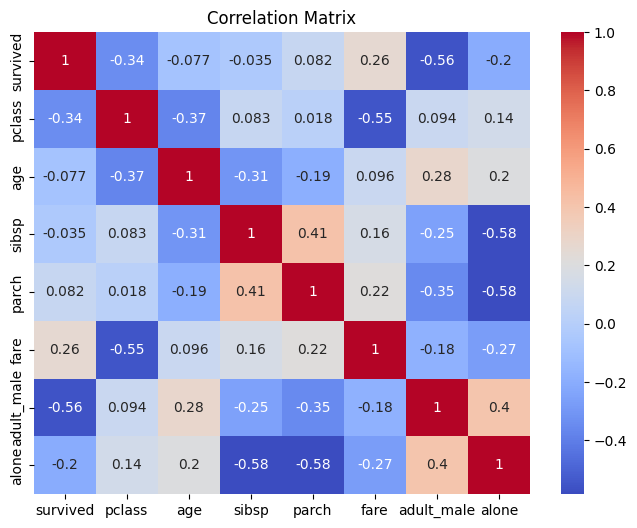

In [67]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [68]:
df = df[['survived','pclass','sex','age','sibsp','parch','fare','embarked']]

In [69]:
df['age'].fillna(df['age'].median(), inplace=True)
df['embarked'].fillna(df['embarked'].mode()[0], inplace=True)

In [70]:
df = pd.get_dummies(df, columns=['sex','embarked'], drop_first=True)

In [71]:
X = df.drop('survived', axis=1)
y = df['survived']

In [72]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [73]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [74]:
log_model = LogisticRegression()
log_model.fit(X_train, y_train)
log_pred = log_model.predict(X_test)

In [75]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

In [76]:
svm_model = SVC()
svm_model.fit(X_train, y_train)
svm_pred = svm_model.predict(X_test)

In [86]:
print("\n" + "="*50)
print(f"{'Logistic Regression':^50}")
print("="*50)

acc = accuracy_score(y_test, log_pred)
prec = precision_score(y_test, log_pred)
rec = recall_score(y_test, log_pred)
f1 = f1_score(y_test, log_pred)

print(f"{'Accuracy':<12}: {acc:.4f}")
print(f"{'Precision':<12}: {prec:.4f}")
print(f"{'Recall':<12}: {rec:.4f}")
print(f"{'F1 Score':<12}: {f1:.4f}")

cm = confusion_matrix(y_test, log_pred)
cm_df = pd.DataFrame(cm,
                     index=["Actual 0", "Actual 1"],
                     columns=["Pred 0", "Pred 1"])

print("\nConfusion Matrix:")
print(cm_df)


               Logistic Regression                
Accuracy    : 0.8101
Precision   : 0.7857
Recall      : 0.7432
F1 Score    : 0.7639

Confusion Matrix:
          Pred 0  Pred 1
Actual 0      90      15
Actual 1      19      55


In [78]:
print("\n" + "="*50)
print(f"{'Random Forest':^50}")
print("="*50)

acc = accuracy_score(y_test, rf_pred)
prec = precision_score(y_test, rf_pred)
rec = recall_score(y_test, rf_pred)
f1 = f1_score(y_test, rf_pred)

print(f"{'Accuracy':<12}: {acc:.4f}")
print(f"{'Precision':<12}: {prec:.4f}")
print(f"{'Recall':<12}: {rec:.4f}")
print(f"{'F1 Score':<12}: {f1:.4f}")

cm = confusion_matrix(y_test, rf_pred)
cm_df = pd.DataFrame(cm,
                     index=["Actual 0", "Actual 1"],
                     columns=["Pred 0", "Pred 1"])

print("\nConfusion Matrix:")
print(cm_df)


                  Random Forest                   
Accuracy    : 0.8212
Precision   : 0.8000
Recall      : 0.7568
F1 Score    : 0.7778

Confusion Matrix:
          Pred 0  Pred 1
Actual 0      91      14
Actual 1      18      56


In [79]:
print("\n" + "="*50)
print(f"{'SVM':^50}")
print("="*50)

acc = accuracy_score(y_test, svm_pred)
prec = precision_score(y_test, svm_pred)
rec = recall_score(y_test, svm_pred)
f1 = f1_score(y_test, svm_pred)

print(f"{'Accuracy':<12}: {acc:.4f}")
print(f"{'Precision':<12}: {prec:.4f}")
print(f"{'Recall':<12}: {rec:.4f}")
print(f"{'F1 Score':<12}: {f1:.4f}")

cm = confusion_matrix(y_test, svm_pred)
cm_df = pd.DataFrame(cm,
                     index=["Actual 0", "Actual 1"],
                     columns=["Pred 0", "Pred 1"])

print("\nConfusion Matrix:")
print(cm_df)


                       SVM                        
Accuracy    : 0.8212
Precision   : 0.8387
Recall      : 0.7027
F1 Score    : 0.7647

Confusion Matrix:
          Pred 0  Pred 1
Actual 0      95      10
Actual 1      22      52


In [80]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "SVM"],
    "Accuracy": [
        accuracy_score(y_test, log_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, svm_pred)
    ],
    "F1 Score": [
        f1_score(y_test, log_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, svm_pred)
    ]
})

results

,Model,Accuracy,F1 Score
0,Logistic Regression,0.810056,0.763889
1,Random Forest,0.821229,0.777778
2,SVM,0.821229,0.764706


In [81]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_rf = grid.best_estimator_

print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': 5, 'n_estimators': 100}


In [82]:
tuned_pred = best_rf.predict(X_test)

evaluate_model("Tuned Random Forest", y_test, tuned_pred)


               Tuned Random Forest                
Accuracy    : 0.8156
Precision   : 0.8361
Recall      : 0.6892
F1 Score    : 0.7556

Confusion Matrix:
          Pred 0  Pred 1
Actual 0      95      10
Actual 1      23      51



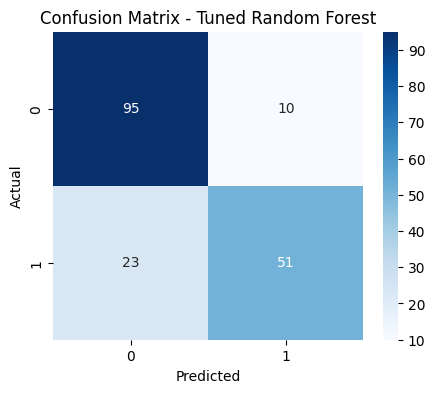

In [83]:
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, tuned_pred),
            annot=True,
            fmt="d",
            cmap="Blues")
plt.title("Confusion Matrix - Tuned Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()